# Import Libaries

In [1]:
import cv2
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
import os
from sklearn.model_selection import train_test_split
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import re


In [ ]:
model_version = "latest"
project_dir = "."

# Define the path of the Project and Import classes

In [ ]:
# os.chdir(r"/home/lcoussy/Yolo_Project_Final")
#os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project")
#os.chdir(r"/home/admin/dev/Yolo_project")

if project_dir != ".":
    os.chdir(project_dir)

print(f"Répertoire de travail : {os.getcwd()}")
print(f"Version du modèle : {model_version}")

train_path = os.path.join("dataset", "train")
valid_path = os.path.join("dataset", "valid")
path_list = [train_path, valid_path]

print(f"Chemins dataset : {path_list}")

data_path = os.path.join("data")

print(f"Chemin data : {data_path}")

from classes.CNN_pytorch_pretrained import CNN_model, YoloDataset, YoloLoss, YOLOv1, YOLO_visual, YOLOVisualizer #import my class CNN

# Import Data

**Download** the dataset used for our training (**Pascal_Voc 2007 and 2012**)

In [ ]:
%run Format_dataset.py #comment it if needed

**Import** our data, **extract** annotations and **encode** them. 

In [ ]:
### old version
#os.chdir(r"/home/lcoussy/Yolo_project/data/Pascal_VOC/train")
#os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\data\Pascal_VOC")
#path_list = [r"/home/lcoussy/Yolo_project/data/Pascal_VOC/train",r"/home/lcoussy/Yolo_project/data/Pascal_VOC/valid"]
#path_list = [r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\data\Pascal_VOC\train",r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\data\Pascal_VOC\valid"]

### new version

# os.chdir(r"/home/lcoussy/Yolo_Project_Final/dataset")
#os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\dataset")
# path_list = [r"/home/lcoussy/Yolo_Project_Final/dataset/train",r"/home/lcoussy/Yolo_Project_Final/dataset/valid"]
#path_list = [r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\dataset\train",r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project\dataset\valid"]

#os.chdir(r"/home/admin/dev/Yolo_project/dataset")
#path_list = [r"/home/admin/dev/Yolo_project/dataset/train",r"/home/lcoussy/Yolo_project/dataset/valid"]

xml_list = []
for path in path_list:
    for filename in os.listdir(path):
        if not filename.endswith('.xml'): continue
        #if should_add(filename):
        fullname = os.path.join(path, filename)
        xml_list.append(fullname)

my_CNN = CNN_model()
my_CNN.get_annotation(xml_list)
my_CNN.encode_pictures()

**Export** our **encoded Datas**

In [ ]:
# os.chdir(r"/home/lcoussy/Yolo_Project_Final")
#os.chdir(r"C:\Users\Lucas\Desktop\vacantion classes\Yolo project")
#os.chdir(r"/home/admin/dev/Yolo_project")

my_CNN.df.to_json(os.path.join(data_path, "annot_df.json"),orient="records")
torch.save(my_CNN.encoded_picture_annot, os.path.join(data_path, "encoded_picture.pt"))

In [ ]:
# Extracted classes :
#my_classes_new = my_CNN.classes
#my_classes_new

In [ ]:
# Classes of our dataset (to change if change the dataset used)
my_classes = ['dog','person','train','sofa','chair','car','pottedplant','diningtable','horse','cat','cow','bicycle','aeroplane','tvmonitor',
              'bird','bottle','motorbike','bus','boat','sheep']

**Load** our **Encoded Dataset**

In [ ]:
df_encoded = torch.load(os.path.join(data_path, "encoded_picture.pt"),weights_only=False)
df_encoded

,file_name,encoded_grid
1,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
2,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
3,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
4,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
5,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
...,...,...
32222,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
32223,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
32224,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
32225,C:\Users\Lucas\Desktop\vacantion classes\Yolo ...,"[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."


# Split our Dataset for training

In [6]:
def split_Voc(X,y,test_size=0.2,random_state=42):
    if test_size == 0:
        X_test = pd.DataFrame()
        y_test = pd.DataFrame()
        return X, X_test, y, y_test
    else:
        return train_test_split(X,y,test_size=test_size, random_state=random_state)

In [7]:
#X_train, X_test, y_train, y_test = train_test_split(df_encoded['file_name'],df_encoded['encoded_grid'],test_size=0.4, random_state=42)

X_train, X_test, y_train, y_test = split_Voc(df_encoded['file_name'],df_encoded['encoded_grid'],test_size=0)

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
#X_train = X_train[:1000]
#y_train = y_train[:1000]

In [9]:
train_dataset = YoloDataset(X_train, y_train)
test_dataset = YoloDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


# Visualization tools

In [10]:
def show_yolo_label(img_tensor, label_tensor, img_size=448, conf_threshold=0.5, S=7):
    # Convert tensor to numpy and back to OpenCV format (HWC)
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img * 255).astype('uint8')
    img = img[..., ::-1].copy()  # RGB -> BGR for OpenCV

    # Draw YOLO grid
    step = img_size // S
    for i in range(1, S):
        # horizontal line
        cv2.line(img, (0, i*step), (img_size, i*step), color=(255, 255, 255), thickness=1)
        # vertical line
        cv2.line(img, (i*step, 0), (i*step, img_size), color=(255, 255, 255), thickness=1)

    # Draw bounding boxes
    if label_tensor.ndim == 3:
        for i in range(S):
            for j in range(S):
                cell = label_tensor[i, j]
                if cell[0] > conf_threshold:  # confidence score
                    x, y, w, h = cell[1:5]
                    # Convert to absolute coords
                    x_center = (j + x) / S * img_size
                    y_center = (i + y) / S * img_size
                    w_pixel = w * img_size
                    h_pixel = h * img_size
                    x1 = int(x_center - w_pixel / 2)
                    y1 = int(y_center - h_pixel / 2)
                    x2 = int(x_center + w_pixel / 2)
                    y2 = int(y_center + h_pixel / 2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    else:
        boxes = label_tensor.view(-1, 5 if label_tensor.shape[-1] == 5 else 4)
        for box in boxes:
            if box.numel() == 5:
                _, x, y, w, h = box
            else:
                x, y, w, h = box
            x1 = int((x - w/2) * img_size)
            y1 = int((y - h/2) * img_size)
            x2 = int((x + w/2) * img_size)
            y2 = int((y + h/2) * img_size)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Show image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


c:\Users\Lucas\Desktop\vacantion classes\Yolo project\classes\CNN_pytorch_pretrained.py:659: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(self.Y_tensor[idx], dtype=torch.float32)


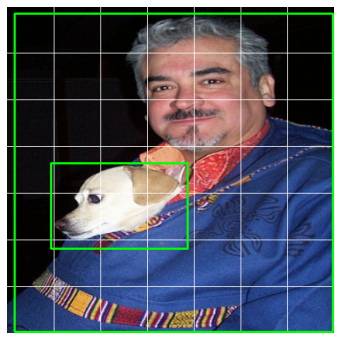

In [11]:
img, label = train_dataset[0]
show_yolo_label(img, label)

In [ ]:
def compare_pred_vs_true(img_tensor, pred_tensor, target_tensor, img_size=448, conf_threshold=0.3):
    """
    Visualize both predicted and ground truth boxes on the same image.
    Predicted boxes: green
    Ground truth boxes: red
    """

    # Convert tensor to numpy image
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * 255).astype('uint8')
    img = img[..., ::-1].copy()  # RGB -> BGR for OpenCV

    S = 7
    step = img_size // S

    for i in range(S):
        for j in range(S):
            # === Ground truth ===
            tcell = target_tensor[i, j]
            if tcell[0] > 0:  # object present
                tx, ty, tw, th = tcell[1:5]
                x_center = (j + tx) / S * img_size
                y_center = (i + ty) / S * img_size
                w_pixel = tw * img_size
                h_pixel = th * img_size
                x1 = int(x_center - w_pixel / 2)
                y1 = int(y_center - h_pixel / 2)
                x2 = int(x_center + w_pixel / 2)
                y2 = int(y_center + h_pixel / 2)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)  # RED = ground truth

            # === Prediction ===
            pcell = pred_tensor[i, j]
            for b in range(2):
                conf = torch.sigmoid(torch.tensor(pcell[0])).item()
                if conf < conf_threshold:
                    continue
                x, y, w, h = pcell[b*5+1:b*5+5]
                x_center = (j + x) / S * img_size
                y_center = (i + y) / S * img_size
                w_pixel = abs(w) * img_size
                h_pixel = abs(h) * img_size
                x1 = int(x_center - w_pixel / 2)
                y1 = int(y_center - h_pixel / 2)
                x2 = int(x_center + w_pixel / 2)
                y2 = int(y_center + h_pixel / 2)
                x1 = max(0, min(x1, img.shape[1] - 1))
                x2 = max(0, min(x2, img.shape[1] - 1))
                y1 = max(0, min(y1, img.shape[0] - 1))
                y2 = max(0, min(y2, img.shape[0] - 1))
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # GREEN = prediction

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("YOLO — Predicted (green) vs Ground Truth (red)")
    plt.axis('off')
    plt.show()

# Training

We train our Yolov1 model using the pre-trained backbone **IMAGENET1K_V1** and **fixing its gradient**. 
We use a **fix learning-rate** contrary to the original paper, and we **clip the gradient** to avoid divergance.


🚀 Starting Training for 80 epochs...



C:\Users\Lucas\AppData\Local\Temp\ipykernel_1740\3285736511.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  conf = torch.sigmoid(torch.tensor(pcell[0])).item()


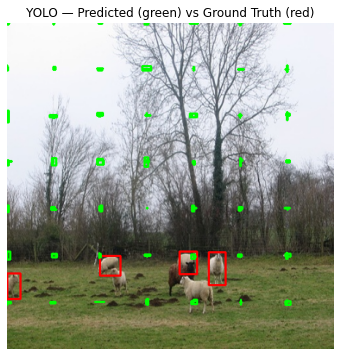

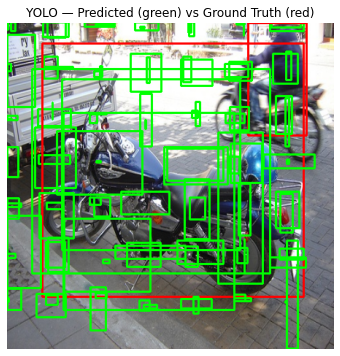

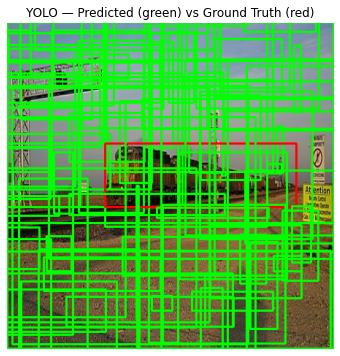

💡 Epoch 1/80 | Loss: 11.3053 | LR: 0.0001
💡 Epoch 2/80 | Loss: 8.1009 | LR: 0.0001
💡 Epoch 3/80 | Loss: 7.2459 | LR: 0.0001
💡 Epoch 4/80 | Loss: 6.7223 | LR: 0.0001
💡 Epoch 5/80 | Loss: 6.2396 | LR: 0.0001
💡 Epoch 6/80 | Loss: 5.6806 | LR: 0.0001
💡 Epoch 7/80 | Loss: 5.2273 | LR: 0.0001
💡 Epoch 8/80 | Loss: 4.8624 | LR: 0.0001
💡 Epoch 9/80 | Loss: 4.4620 | LR: 0.0001


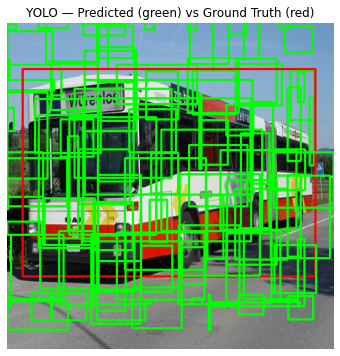

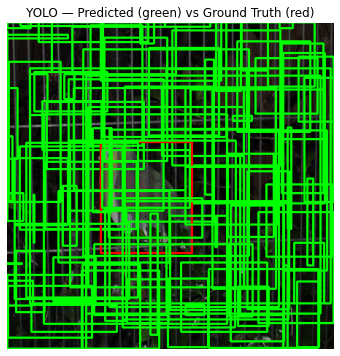

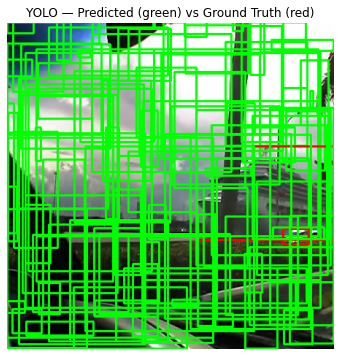

💡 Epoch 10/80 | Loss: 4.0764 | LR: 0.0001
💡 Epoch 11/80 | Loss: 3.8440 | LR: 0.0001
💡 Epoch 12/80 | Loss: 3.6040 | LR: 0.0001
💡 Epoch 13/80 | Loss: 3.3016 | LR: 0.0001
💡 Epoch 14/80 | Loss: 3.1262 | LR: 0.0001
💡 Epoch 15/80 | Loss: 2.9572 | LR: 0.0001
💡 Epoch 16/80 | Loss: 2.9123 | LR: 0.0001
💡 Epoch 17/80 | Loss: 2.7527 | LR: 0.0001
💡 Epoch 18/80 | Loss: 2.6094 | LR: 0.0001


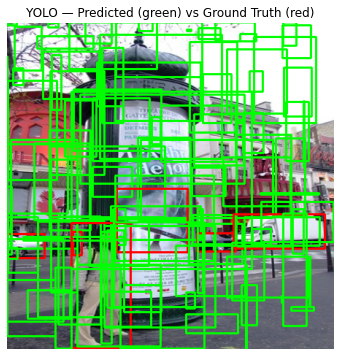

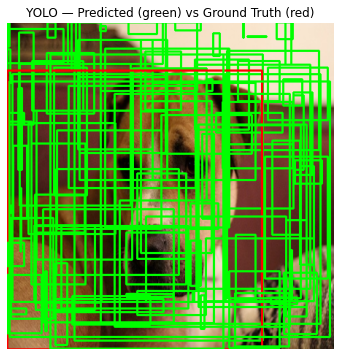

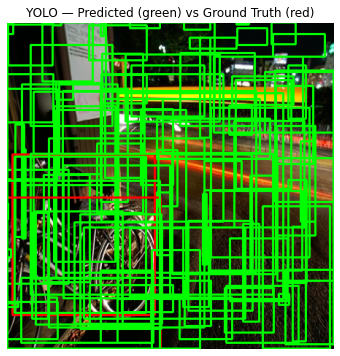

💡 Epoch 19/80 | Loss: 2.4610 | LR: 0.0001
💡 Epoch 20/80 | Loss: 2.3511 | LR: 0.0001
💡 Epoch 21/80 | Loss: 2.3336 | LR: 0.0001
💡 Epoch 22/80 | Loss: 2.1924 | LR: 0.0001
💡 Epoch 23/80 | Loss: 2.1228 | LR: 0.0001
💡 Epoch 24/80 | Loss: 2.0323 | LR: 0.0001
💡 Epoch 25/80 | Loss: 1.9747 | LR: 0.0001
💡 Epoch 26/80 | Loss: 1.9356 | LR: 0.0001
💡 Epoch 27/80 | Loss: 1.8260 | LR: 0.0001


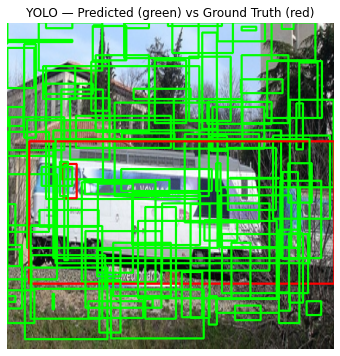

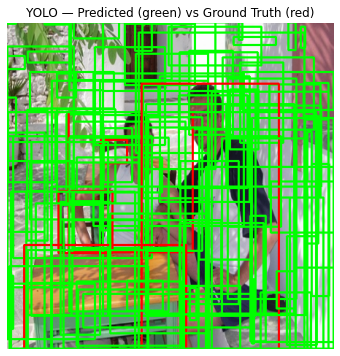

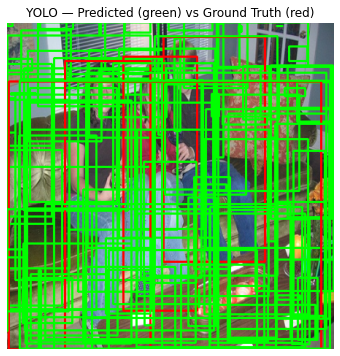

💡 Epoch 28/80 | Loss: 1.8567 | LR: 0.0001
💡 Epoch 29/80 | Loss: 1.7816 | LR: 0.0001
💡 Epoch 30/80 | Loss: 1.7062 | LR: 0.0001
💡 Epoch 31/80 | Loss: 1.6341 | LR: 0.0001
💡 Epoch 32/80 | Loss: 1.6475 | LR: 0.0001
💡 Epoch 33/80 | Loss: 1.5411 | LR: 0.0001
💡 Epoch 34/80 | Loss: 1.5008 | LR: 0.0001
💡 Epoch 35/80 | Loss: 1.4546 | LR: 0.0001
💡 Epoch 36/80 | Loss: 1.4838 | LR: 0.0001


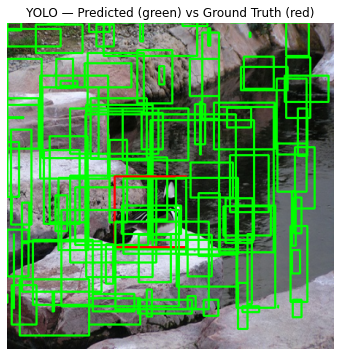

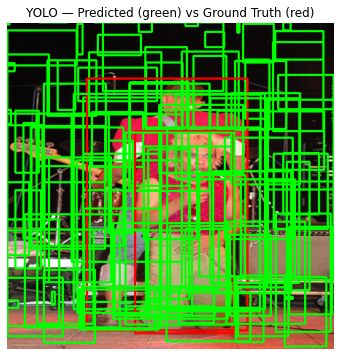

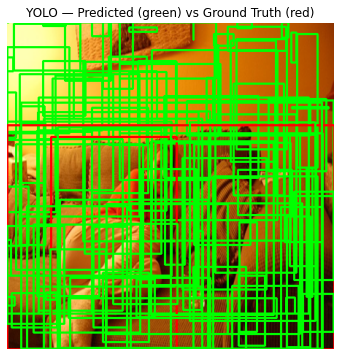

💡 Epoch 37/80 | Loss: 1.4285 | LR: 0.0001
💡 Epoch 38/80 | Loss: 1.4343 | LR: 0.0001
💡 Epoch 39/80 | Loss: 1.3774 | LR: 0.0001
💡 Epoch 40/80 | Loss: 1.3665 | LR: 0.0001
💡 Epoch 41/80 | Loss: 1.3263 | LR: 0.0001
💡 Epoch 42/80 | Loss: 1.2834 | LR: 0.0001
💡 Epoch 43/80 | Loss: 1.2988 | LR: 0.0001
💡 Epoch 44/80 | Loss: 1.2474 | LR: 0.0001
💡 Epoch 45/80 | Loss: 1.2294 | LR: 0.0001


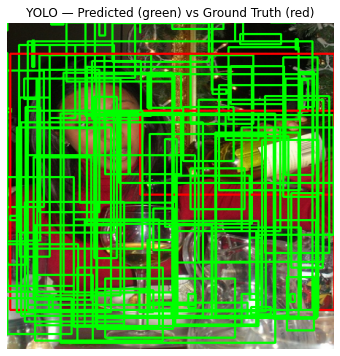

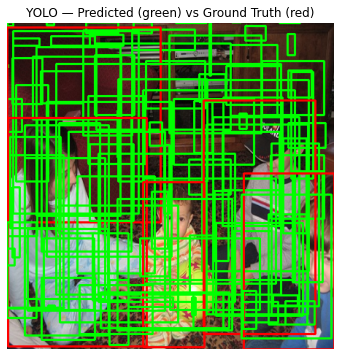

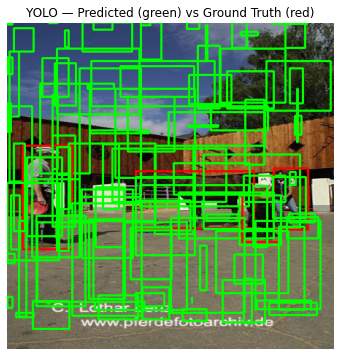

💡 Epoch 46/80 | Loss: 1.2312 | LR: 0.0001
💡 Epoch 47/80 | Loss: 1.1698 | LR: 0.0001
💡 Epoch 48/80 | Loss: 1.1374 | LR: 0.0001
💡 Epoch 49/80 | Loss: 1.1433 | LR: 0.0001
💡 Epoch 50/80 | Loss: 1.1543 | LR: 0.0001
💡 Epoch 51/80 | Loss: 1.1045 | LR: 0.0001
💡 Epoch 52/80 | Loss: 1.1435 | LR: 0.0001
💡 Epoch 53/80 | Loss: 1.1410 | LR: 0.0001
💡 Epoch 54/80 | Loss: 1.0928 | LR: 0.0001


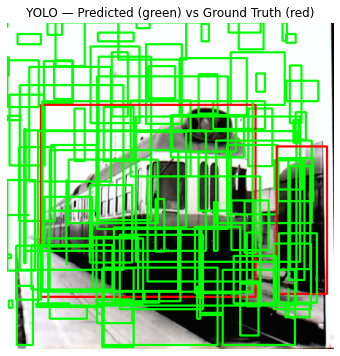

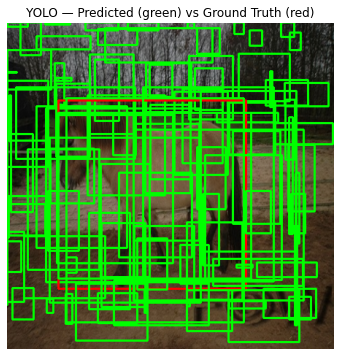

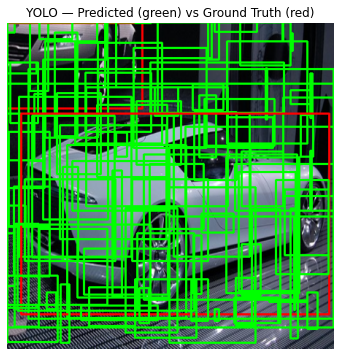

💡 Epoch 55/80 | Loss: 1.0791 | LR: 0.0001
💡 Epoch 56/80 | Loss: 1.0808 | LR: 0.0001
💡 Epoch 57/80 | Loss: 1.0423 | LR: 0.0001
💡 Epoch 58/80 | Loss: 1.0330 | LR: 0.0001
💡 Epoch 59/80 | Loss: 1.0353 | LR: 0.0001
💡 Epoch 60/80 | Loss: 1.0940 | LR: 0.0001
💡 Epoch 61/80 | Loss: 1.0065 | LR: 0.0001
💡 Epoch 62/80 | Loss: 0.9904 | LR: 0.0001
💡 Epoch 63/80 | Loss: 0.9729 | LR: 0.0001


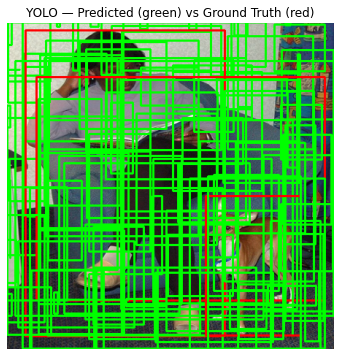

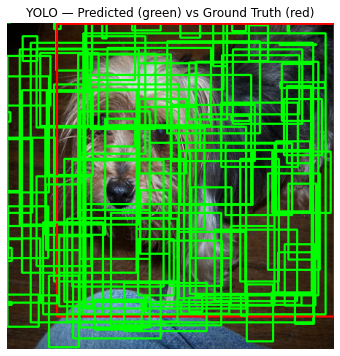

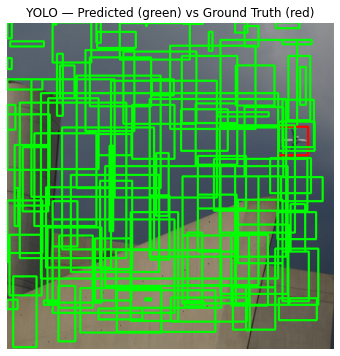

💡 Epoch 64/80 | Loss: 0.9932 | LR: 0.0001
💡 Epoch 65/80 | Loss: 0.9392 | LR: 0.0001
💡 Epoch 66/80 | Loss: 0.9378 | LR: 0.0001
💡 Epoch 67/80 | Loss: 0.9440 | LR: 0.0001
💡 Epoch 68/80 | Loss: 0.9436 | LR: 0.0001
💡 Epoch 69/80 | Loss: 0.8874 | LR: 0.0001
💡 Epoch 70/80 | Loss: 0.8978 | LR: 0.0001
💡 Epoch 71/80 | Loss: 0.9236 | LR: 0.0001
💡 Epoch 72/80 | Loss: 0.8849 | LR: 0.0001


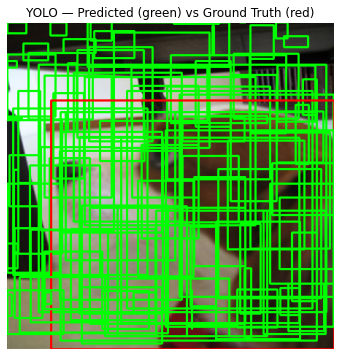

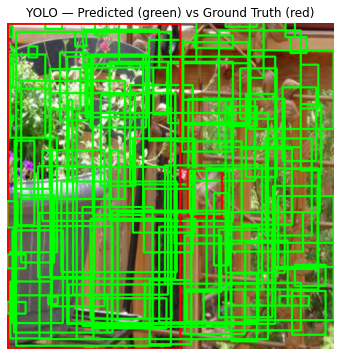

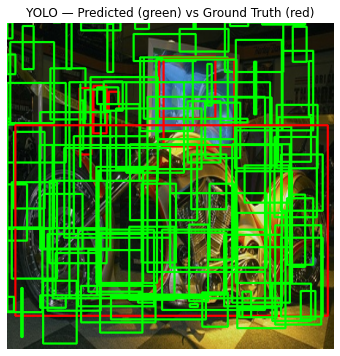

💡 Epoch 73/80 | Loss: 0.8402 | LR: 0.0001
💡 Epoch 74/80 | Loss: 0.8619 | LR: 0.0001
💡 Epoch 75/80 | Loss: 0.8687 | LR: 0.0001
💡 Epoch 76/80 | Loss: 0.8540 | LR: 0.0001
💡 Epoch 77/80 | Loss: 0.9055 | LR: 0.0001
💡 Epoch 78/80 | Loss: 0.8739 | LR: 0.0001
💡 Epoch 79/80 | Loss: 0.8615 | LR: 0.0001
💡 Epoch 80/80 | Loss: 0.8761 | LR: 0.0001

💾 Model saved as yolov1_trained5.pth



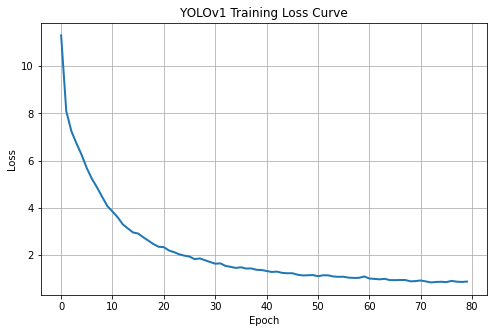

In [ ]:
torch.cuda.empty_cache()

# -------------------------------
# 1️⃣ Hyperparameters
# -------------------------------
S, B, C = 7, 2, 20
batch_size = 32

num_epochs = 130
device = "cuda"

my_model = YOLOv1(S=S, B=B, C=C, pretrained=True).to(device)

for name, p in my_model.named_parameters():
    if 'features' in name:
        p.requires_grad = False
    else:
        p.requires_grad = True 
    
criterion = YoloLoss(S=S, B=B, C=C, l_obj=5, l_nobj=0.5)

# ❗ FIXED learning rate (no warmup, no decay)
optimizer = optim.Adam(my_model.parameters(), lr=1e-4)

train_losses = []

print(f"\n🚀 Starting Training for {num_epochs} epochs...\n")

# -------------------------------
# 2️⃣ Training Loop
# -------------------------------
for epoch in range(num_epochs):
    my_model.train()
    running_loss = 0.0
    display_count = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False, disable=True):

        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        preds = my_model(imgs)

        # Optional visualization
        if epoch % 9 == 0 and display_count < 3:
            compare_pred_vs_true(imgs[0].cpu(), preds[0], target_tensor=labels[0])
            display_count += 1

        loss = criterion.yolo_loss_vectorized(preds, labels)
        loss.backward()

        # (optional) gradient clipping
        torch.nn.utils.clip_grad_norm_(my_model.parameters(), 5)

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"💡 Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | LR: 0.0001")

# -------------------------------
# 3️⃣ Save Model
# -------------------------------
os.makedirs("slurm/output/models", exist_ok=True)
save_path = os.path.join("slurm", "output", "models", f"yolov1_trained_{model_version}.pth")
torch.save(my_model.state_dict(), save_path)
print(f"\n💾 Model saved as {save_path}\n")

# -------------------------------
# 4️⃣ Plot Training Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, linewidth=2)
plt.title("YOLOv1 Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
S, B, C = 7, 2, 20

model = YOLOv1(S=S, B=B, C=C).to(device)
criterion = YoloLoss(S=S, B=B, C=C)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

loaded_model = YOLOv1(S=S, B=B, C=C).to(device)
loaded_model.load_state_dict(torch.load("slurm/output/yolov1_trained5.pth", map_location=device))
loaded_model.eval()
print("🔁 Loaded model from yolov1_trained5.pth")

# -------------------------------
# 7️⃣ Evaluate on Test Set
# -------------------------------

Train_loss = 0.0
with torch.no_grad():
    for imgs, labels in tqdm(train_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        print("imgs",imgs.shape)
        preds = loaded_model(imgs)
        loss = criterion.yolo_loss_stable(preds, labels)
        Train_loss += loss.item()

avg_train_loss = Train_loss / len(train_loader)
print(f"\n📊 Train Loss: {avg_train_loss:.4f}")


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

🔁 Loaded model from yolov1_trained5.pth
imgs torch.Size([32, 3, 448, 448])


Evaluating:   3%|▎         | 1/32 [00:02<01:05,  2.13s/it]

imgs torch.Size([32, 3, 448, 448])


Evaluating:   6%|▋         | 2/32 [00:03<00:57,  1.93s/it]

...

imgs torch.Size([32, 3, 448, 448])


Evaluating:  97%|█████████▋| 31/32 [00:47<00:01,  1.50s/it]

imgs torch.Size([8, 3, 448, 448])


Evaluating: 100%|██████████| 32/32 [00:47<00:00,  1.48s/it]


📊 Train Loss: 17.7013


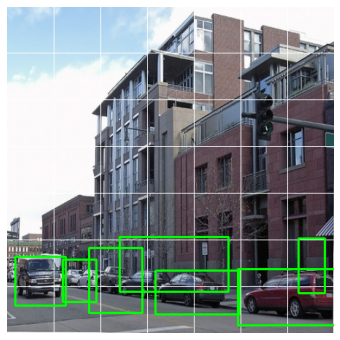

In [15]:
a = train_dataset[3][0]
a = a.unsqueeze(0).to(device)
with torch.no_grad():
    out1 = loaded_model(a)

show_yolo_label(a[0].cpu(), out1[0], img_size=448, conf_threshold=0.2, S=7)

Prediction difference: 1.248424768447876


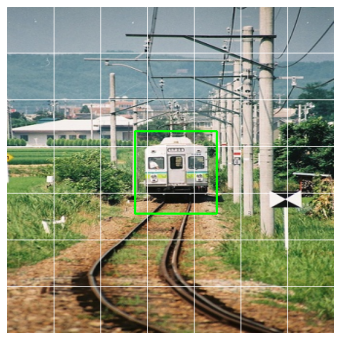

In [16]:
a = train_dataset[0][0]
b = train_dataset[1][0]
a = a.unsqueeze(0).to(device)
b = b.unsqueeze(0).to(device)
with torch.no_grad():
    out1 = loaded_model(a)
    out2 = loaded_model(b)

print("Prediction difference:", (out1 - out2).abs().max().item())
a = train_dataset[0][0]
b = train_dataset[1][0]
show_yolo_label(b, out2[0], img_size=448, conf_threshold=0.5, S=7)

In [ ]:
S, B, C = 7, 2, 20

device = 'cuda'

loaded_model = YOLOv1(S=S, B=B, C=C).to(device)
loaded_model.load_state_dict(torch.load("slurm/output/yolov1_trained1.pth", map_location=device))
loaded_model.eval()

YOLOv1(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=1e-05

In [18]:
def yolo_viz(img_tensor, pred_tensor, target_tensor=None, img_size=448, conf_threshold=0.3):
    """
    Visualize both predicted and ground truth boxes on the same image.
    Predicted boxes: green
    Ground truth boxes: red
    """

    
    # Convert tensor to numpy image
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * 255).astype('uint8')
    img = img[..., ::-1].copy()  # RGB -> BGR for OpenCV

    S = 7
    step = img_size // S
    for i in range(S):
        for j in range(S):
            if target_tensor is not None:
                # === Ground truth ===
                tcell = target_tensor[i, j]
                if tcell[0] > 0:  # object present
                    tx, ty, tw, th = tcell[1:5]
                    label = my_classes[torch.argmax(tcell[B*5:])]
                    label = f"{label} : {tcell[0]}"
                    x_center = (j + tx) / S * img_size
                    y_center = (i + ty) / S * img_size
                    w_pixel = tw * img_size
                    h_pixel = th * img_size
                    x1 = int(x_center - w_pixel / 2)
                    y1 = int(y_center - h_pixel / 2)
                    x2 = int(x_center + w_pixel / 2)
                    y2 = int(y_center + h_pixel / 2)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)  # RED = ground truth
                    cv2.putText(img, label, (x1, y1 - 5),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (36,255,12), 1)
            # === Prediction ===
            pcell = pred_tensor[i, j]
            for b in range(2):
                conf = torch.sigmoid(torch.tensor(pcell[0])).item()
                print(conf)
                if conf < conf_threshold:
                    continue
                label = my_classes[torch.argmax(pcell[B*5:])]
                label = f"{label} : {pcell[0]}"
                x, y, w, h = pcell[b*5+1:b*5+5]
                x_center = (j + x) / S * img_size
                y_center = (i + y) / S * img_size
                w_pixel = abs(w) * img_size
                h_pixel = abs(h) * img_size
                x1 = int(x_center - w_pixel / 2)
                y1 = int(y_center - h_pixel / 2)
                x2 = int(x_center + w_pixel / 2)
                y2 = int(y_center + h_pixel / 2)
                x1 = max(0, min(x1, img.shape[1] - 1))
                x2 = max(0, min(x2, img.shape[1] - 1))
                y1 = max(0, min(y1, img.shape[0] - 1))
                y2 = max(0, min(y2, img.shape[0] - 1))
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # GREEN = prediction
                cv2.putText(img, label, (x1, y1 - 5),cv2.FONT_HERSHEY_SIMPLEX, 0.6, (36,255,12), 1)
    #plt.figure(figsize=(6,6))
    #plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    #plt.title("YOLO — Predicted (green) vs Ground Truth (red)")
    #plt.axis('off')
    #plt.show()
    return img

In [19]:
#cap = cv2.VideoCapture(0)  # or 0 for camera
cap = cv2.VideoCapture("mixkit-play-between-two-teams-in-a-soccer-match-43481-hd-ready.mp4")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
desired_size = (480,480)
out = cv2.VideoWriter("output.mp4", fourcc, 20.0, desired_size)

while True:
    ret, img = cap.read()
    if not ret:
        break
    
    img = cv2.resize(img, (448, 448))
    img = img[..., ::-1]  # BGR to RGB
    img = img / 255.0
    img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).float()  # (C,H,W)
    #frame_tensor = frame_tensor.to(next(model.parameters()).device)

    img = img.to('cuda')
    results = loaded_model(img)
    #print(results)
    frame_out = yolo_viz(img[0], results[0], conf_threshold=0.61)

    # Write to video and display in real-time
    out.write(frame_out)
    cv2.imshow("YOLO Detection", frame_out)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
out.release()
cv2.destroyAllWindows()


C:\Users\Lucas\AppData\Local\Temp\ipykernel_1740\127747812.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  conf = torch.sigmoid(torch.tensor(pcell[0])).item()


0.49725398421287537
0.49725398421287537
0.48826390504837036
0.48826390504837036
0.4867895543575287
0.4867895543575287
0.4972355365753174
0.4972355365753174
0.5047193169593811
0.5047193169593811
0.49978241324424744
0.49978241324424744
0.49540573358535767
0.49540573358535767
0.4886758625507355
0.4886758625507355
0.5066161751747131
0.5066161751747131
0.570604145526886
0.570604145526886
0.5015537738800049
0.5015537738800049
0.5132310390472412
0.5132310390472412
0.5395621061325073
0.5395621061325073
0.4974929094314575
0.4974929094314575
0.6433974504470825
0.6433974504470825
0.6731350421905518
0.6731350421905518
0.5408538579940796
0.5408538579940796
0.5488133430480957
0.5488133430480957
0.5714696049690247
0.5714696049690247
0.5172102451324463
0.5172102451324463
0.5751914978027344
0.5751914978027344
0.5455513596534729
0.5455513596534729
0.6544459462165833
0.6544459462165833
0.6557762026786804
0.6557762026786804
0.6061699986457825
0.6061699986457825
0.6314603686332703
0.6314603686332703
0.5707

In [20]:
x_path = "horse_racing.jpg"

img = cv2.imread(x_path)
img = cv2.resize(img, (448, 448))
img = img[..., ::-1]  # BGR to RGB
img = img / 255.0
img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)  # (C,H,W)

img = img.to('cuda')
pred = model(img.unsqueeze(0))
pred = pred.to('cuda')

compare_pred_vs_true(img,pred_tensor=pred[0], conf_threshold=0.61)


TypeError: compare_pred_vs_true() missing 1 required positional argument: 'target_tensor'